# Data Exploration 2: Visual Data Exploration
```
Course: ENV 700 - Environmental Data Exploration
Authors: John Fay & Luana Lima
```

## Lesson Objectives
By the end of this lesson, you should be able to:
1. Create basic exploratory visualizations from a Pandas DataFrame using built-in plotting methods.
2. Select appropriate plot types (histograms, boxplots, scatterplots, and bar charts) for different types of variables and questions.
3. Use visualizations to identify patterns in data, including distributions, trends, relationships, and group differences.
4. Detect potential data-quality issues such as missing values, outliers, unusual distributions, and possible data-entry errors.
5. Interpret exploratory plots and use their results to guide subsequent data wrangling and analysis decisions.

---
## Discussion: Why do we explore our data?
Why is data exploration our first step in analyzing a dataset? What information do we gain? How does data exploration aid in our decision-making for data analysis steps further down the pipeline?

>Answer: 
>

## A. Import data and view summaries

#### 1. Load libraries
Import the `Path` and `Pandas` libraries.  

In [4]:
#Import packages
from pathlib import Path
import pandas as pd

#### 2. Create path objects
Create path objects for the project root folder and the raw subfolder of the data folder. 

In [12]:
#Create path objects for the root, and both the raw & processed subfolders of the data folders
root_fldr = Path.cwd().parent.parent
raw_fldr = root_fldr / 'data' / 'raw'
processed_fldr = root_fldr / 'data' / 'processed'

print(processed_fldr)

/Users/matthewswire/Desktop/Duke/Fall_2026/Data_Exploration/ENV700/data/processed


#### 3. Import datasets
Import the *processed* dataset created in Part 1:  `USGS_Site02085000_Flow_Processed.csv`. 
* Read in the `site_no` column as a category
* Read in the `datetime` column as a date time object 

In [13]:
#Import the processed USGS flow data
USGS_flow_data = pd.read_csv(
    processed_fldr/'USGS_Site02085000_Flow_Processed.csv',
    dtype={'site_no':'category'},
    parse_dates=['datetime']
    )

#### 4. View summaries of the dataset
* Dimensions
* Column names
* Full structure & information 
* Summary stats for numeric colunmns

In [14]:
#Show the dimensions
USGS_flow_data.shape

(30848, 19)

In [15]:
#Column names
USGS_flow_data.columns

Index(['agency_cd', 'site_no', 'datetime', 'discharge_max',
       'discharge_max_approval', 'discharge_min', 'discharge_min_approval',
       'discharge_mean', 'discharge_mean_approval', 'gage_height_max',
       'gage_height_max_approval', 'gage_height_min',
       'gage_height_min_approval', 'gage_height_mean',
       'gage_height_mean_approval', 'year', 'month', 'day_of_year', 'weekday'],
      dtype='str')

In [16]:
#Full structure information 
USGS_flow_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30848 entries, 0 to 30847
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   agency_cd                  30848 non-null  str           
 1   site_no                    30848 non-null  category      
 2   datetime                   30848 non-null  datetime64[us]
 3   discharge_max              5348 non-null   float64       
 4   discharge_max_approval     5348 non-null   str           
 5   discharge_min              5348 non-null   float64       
 6   discharge_min_approval     5348 non-null   str           
 7   discharge_mean             30848 non-null  float64       
 8   discharge_mean_approval    30848 non-null  str           
 9   gage_height_max            5461 non-null   float64       
 10  gage_height_max_approval   5461 non-null   str           
 11  gage_height_min            5461 non-null   float64       
 12  gage_height_min

In [17]:
#View summary statistics
USGS_flow_data.describe()

,datetime,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean,year,month,day_of_year
count,30848,5348.000000,5348.000000,30848.000000,5461.000000,5461.000000,11161.000000,30848.000000,30848.000000,30848.000000
mean,1976-12-18 14:32:55.518672,88.147554,30.462292,59.668283,2.123613,1.735719,1.987142,1976.467129,6.506256,182.610412
min,1928-01-01 00:00:00,0.260000,0.090000,0.020000,0.890000,0.840000,0.870000,1928.000000,1.000000,1.000000
25%,1949-02-10 18:00:00,7.230000,4.380000,9.200000,1.490000,1.380000,1.500000,1949.000000,4.000000,91.000000
50%,1970-03-24 12:00:00,21.150000,12.600000,24.000000,1.830000,1.650000,1.810000,1970.000000,7.000000,182.000000
75%,2005-04-29 06:00:00,59.800000,34.800000,53.325000,2.310000,2.030000,2.210000,2005.000000,10.000000,274.000000
max,2026-06-10 00:00:00,4730.000000,1460.000000,8180.000000,17.020000,9.190000,15.040000,2026.000000,12.000000,366.000000
std,NaN,282.801800,61.329289,158.730953,1.416646,0.587740,0.919247,30.630066,3.449917,105.473319


In [18]:
#List unique values in a categorical field
USGS_flow_data['gage_height_mean_approval'].unique()

<StringArray>
[nan, 'A', 'P']
Length: 3, dtype: str

In [19]:
#Count the number of records with each unique value
USGS_flow_data['gage_height_mean_approval'].value_counts()

gage_height_mean_approval
A    11047
P      114
Name: count, dtype: int64

#### 👉 You try it: 
* List all the unique values in the `month` field. 
* Show the count of records in each month
* Try chaining `.sort_index()` or `.sort_values()` to the `value_counts()` statement.

In [39]:
#List the number of records associated with each month
USGS_flow_data['month'].unique()


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [38]:
#List the number of records associated with each month, in decreasing order with ascending = False 
USGS_flow_data['month'].value_counts().sort_index(ascending=False)


month
12    2604
11    2520
10    2610
9     2520
8     2604
7     2604
6     2530
5     2635
4     2550
3     2635
2     2401
1     2635
Name: count, dtype: int64

--- 
## B. Visualization for Data Exploration
Although the `info()` and `describe()` functions are helpful in getting an idea of the count and spread of values in a numeric dataset, **visual representations** of the data summaries we generated above engage the brain far more efficiently and can help form hypotheses and direct downstream data analysis. 

Pandas offers a limited set of visualization tools throught its `plot()` function which we'll explore here. Later, we'll take a deeper dive into some more complex visualization packages and visualization techniques, but for now, we'll focus on quick, simple visualization types we can do within Pandas.  

As we review the syntax for plotting in Pandas, take note of how whether the plots combine categorical and continuous data and what modifiers are available for each *kind* of plot.   
<https://pandas.pydata.org/docs/user_guide/visualization.html#basic-plotting-plot>

### [1. Bar plots](https://pandas.pydata.org/docs/user_guide/visualization.html#bar-plots)
**Visualize the distribution of records across different *categories*.** 


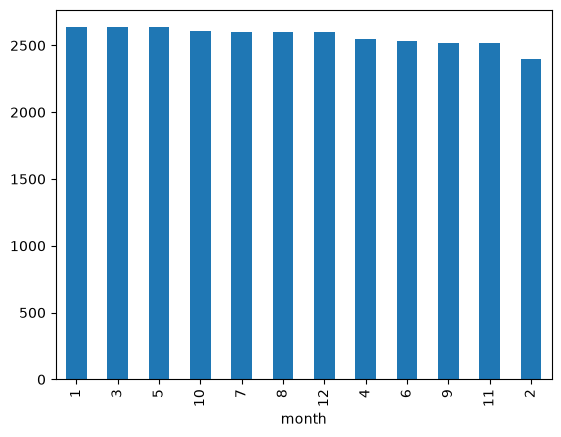

In [45]:
#Bar plot of showing record count by month 
USGS_flow_data['month'].value_counts().plot(kind='bar');

🔥 *Sorting the values often makes a more communicative bar plot.*   
🔥 *Try `barh` instead of `bar`...* 

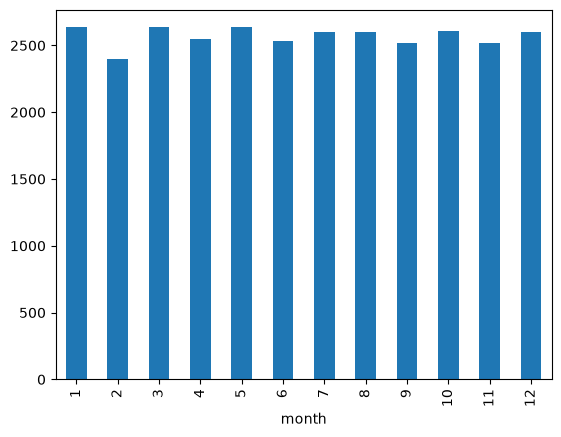

In [ ]:
# SOLUTION
USGS_flow_data['month'].value_counts().sort_index().plot(kind='bar');


#### 👉 You try it: 
Create a plot comparing the numbers of "approved" vs "provisional" mean gage height records, i.e. the unique values in the `gage_height_mean_approval` field.

<Axes: xlabel='discharge_mean_approval'>

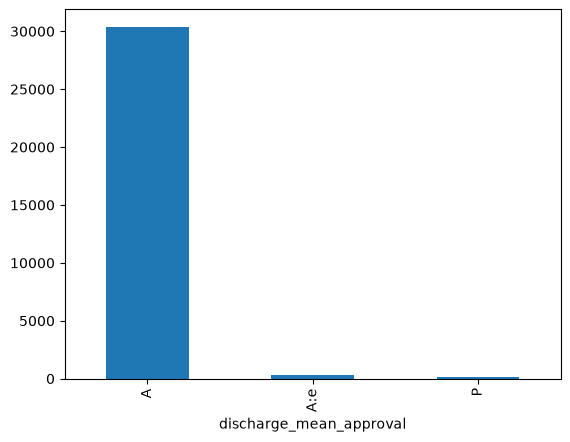

In [48]:
#Bar plot showing record count by approval status
USGS_flow_data['discharge_mean_approval'].value_counts().sort_index().plot(kind='bar')

### [2. Histogram](https://pandas.pydata.org/docs/user_guide/visualization.html#histograms)
**Visualize distributions of values for continuous numerical variables.**  
[Link to image showing differnt *types* of distributions](https://media.licdn.com/dms/image/v2/D5612AQETsP8jjoT9BQ/article-inline_image-shrink_1000_1488/article-inline_image-shrink_1000_1488/0/1721195308816?e=2147483647&v=beta&t=djnRxs35nqGl9SOcVp3svs4ItwE8-Y9HoeU9M3MyysQ)

<Axes: ylabel='Frequency'>

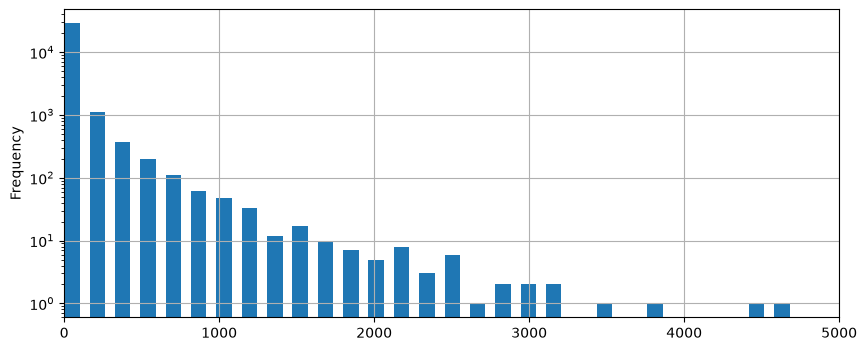

In [62]:
#Histogram of mean discharge values
USGS_flow_data['discharge_mean'].plot(
    kind='hist',
    xlim=(0,5000),
    bins = 50,
    logy= True,
    figsize= (10,4), #figuresize for graph
    width = 100, #for width of bars
    grid = True #adds a grid to the graph
)


Try with the following arguments and explore what they do to the plot: 
* `xlim = (0, 5000)`
* `bins = 50` or `bins = 'fd'`
* `logy = True`
* `figsize = (10,4)`
* `width = 100`

#### 👉 You try it: 
Create a histogram showing the distributin of maximum gage height.
* Set the range on the x axis from 0 to 6
* Use 20 bins
* Set the figure size to 10 x 4
* Use the default bar width

→ *How many peaks do you see in this distribution?*  
→ *Change the plot to use 120 bins; do you get the same number of peaks?*

### [3. Overlayed Density Curves](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.kde.html)
**Visualize multiple continuous distributions simultaneously**

An alternate to a histogram is a **kernel density estimation (KDE)** plot. Instead of dividing data into bins and plotting the number of records in each bin, a KDE plot converts each data point to a distribution "bump" and displays the sum accumulation of these bumps. This allows us to plot the distribution as a continuous line, and this allows us to plot mulitiple distributions on the same axes. 

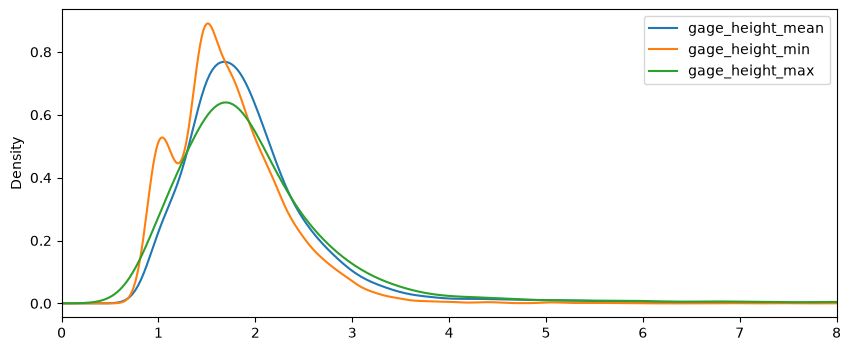

In [65]:
#KDE plot of mean, min, and max discharge record counts
USGS_flow_data[['gage_height_mean','gage_height_min','gage_height_max']].plot(kind='kde', figsize=(10,4), xlim = (0,8));

👉 Modify the above plot so the figure size is 10 x 4 and the x-values are clipped to values between 0 and 8.  
🤔 Be sure you understand why `gage_height_min` has a higher peak than `gage_height_max`. 

#### 👉 You try it: 
Create a kernel density plot allowing us to compare the distributions of min, max, and mean discharge. Restrict values to those between -200 and 200 cfs.  
→ *Does it make sense that we have values below zero?*

<Axes: ylabel='Density'>

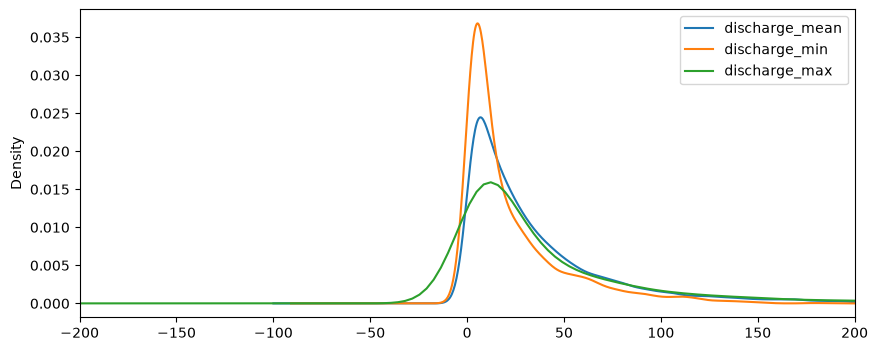

In [76]:
filtered_discharge_mean = USGS_flow_data[
    (USGS_flow_data['discharge_mean'] >= -200) & 
    (USGS_flow_data['discharge_mean'] <= 200)
]

filtered_discharge_mean[['discharge_mean','discharge_min','discharge_max']].plot(
    kind='kde', 
    figsize=(10,4), 
    xlim=(-200, 200)
)



### [4. Box-and-whisker plots](https://pandas.pydata.org/docs/user_guide/visualization.html#box-plots)
*Note the different syntax options*

**Another alternative to histograms (distributions of values for continuous numerical variables).**

These plots consist of: 
* A box from the 25th to the 75th percentile of the data, called the interquartile range (IQR).
* A bold line inside the box representing the median value of the data. Whether the median is in the center or off to one side of the IQR will give you an idea about the skewness of your data.
* A line outside of the box representing values falling within 1.5 times the IQR. 
* Points representing outliers, values that fall outside 1.5 times the IQR. 

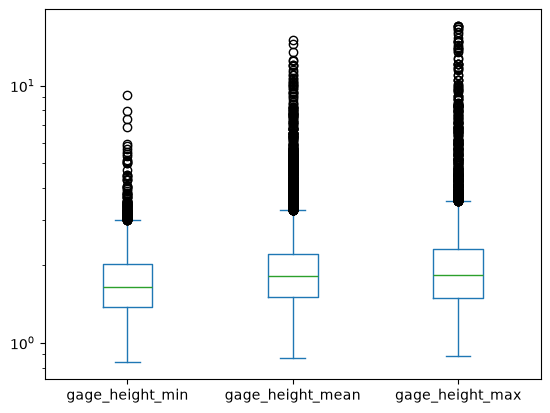

In [77]:
#Box plots of gaget height min, mean, max
USGS_flow_data[['gage_height_min','gage_height_mean','gage_height_max']].plot(kind='box',logy=True);

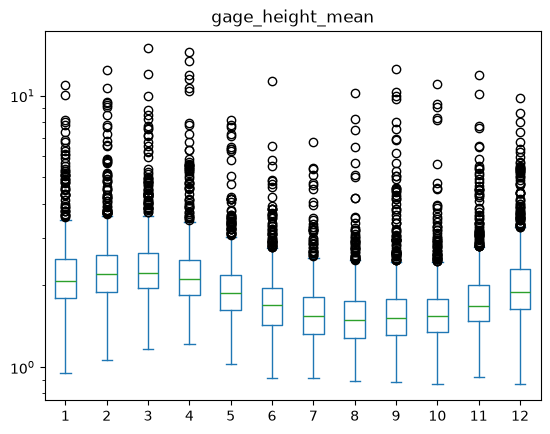

In [99]:
# Various syntax of box plots to show distributions across a grouping variable
USGS_flow_data[['gage_height_mean','month']].plot(kind='box',by='month',logy=True);
#USGS_flow_data[['gage_height_mean','month']].boxplot(by='month');
#USGS_flow_data.boxplot(column=['gage_height_mean'],by='month');

#### 👉 You try it: 
Create a box plot comparing mean gage height between approved and provisional records.  
→ Which grouping has the smaller distribution?  
→ What's a likely reason for the above?  
→ Is that reason supported by the box plot?

gage_height_mean    Axes(0.125,0.11;0.775x0.77)
dtype: object

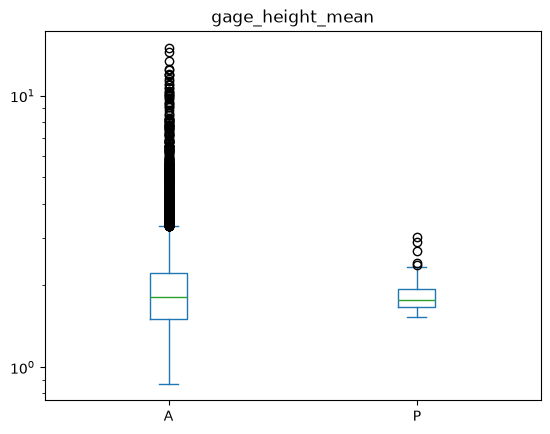

In [93]:
# Comparison of gage height between approved and provisional records
USGS_flow_data[['gage_height_mean_approval','gage_height_mean']].plot(
    kind='box',
    by='gage_height_mean_approval',
    logy=True)

#### 💥Bonus Preview
As a sample of what more powerful plotting packages can do, and also to see variations on the box plot, below is code using the **Seaborn** package to create a **violin plot**, which displays density distributions, somewhat like a hybrid of the box-and-whiskers and the frequency polygon plot.

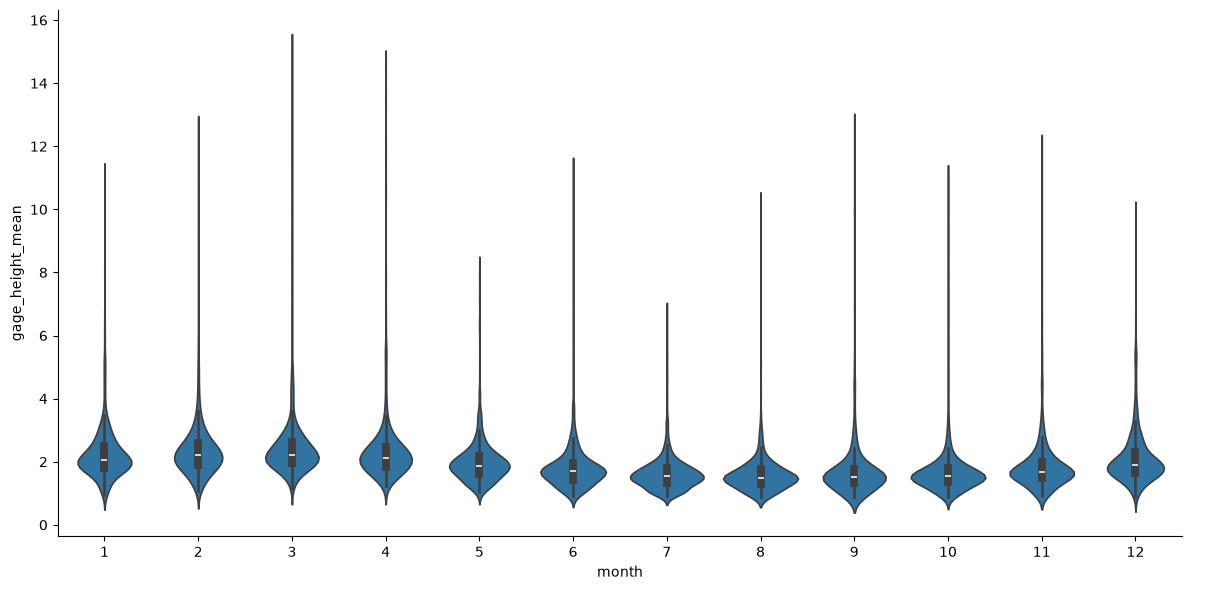

In [ ]:
import seaborn as sns
sns.catplot(
    data = USGS_flow_data,
    x = 'month',
    y = 'gage_height_mean',
    kind='violin',
    #kind='boxen',
    height=6,
    aspect=2
);

### [5. Visualizing relationships: Scatterplot](https://pandas.pydata.org/docs/user_guide/visualization.html#scatter-plot)
**A scatterplot is used to explore relationships between two continuous variables.**
* Try adding `alpha=0.2` as an argument. What does "alpha" control? Why is it useful here?

<Axes: xlabel='discharge_mean', ylabel='gage_height_mean'>

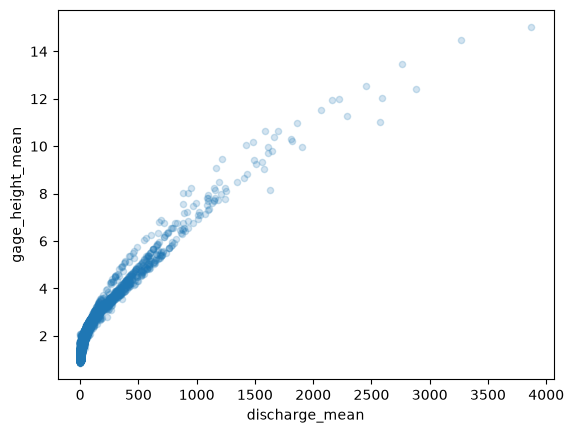

In [102]:
#Plot mean gage height vs mean discharge
USGS_flow_data.plot(
    kind='scatter', 
    x='discharge_mean',
    y='gage_height_mean',
    alpha =0.2
    )

#### 👉 You try it: 
Plot mean discharge against time, setting alpha to 0.2. 
* What do you notice about the data? 

<Axes: xlabel='year', ylabel='discharge_mean'>

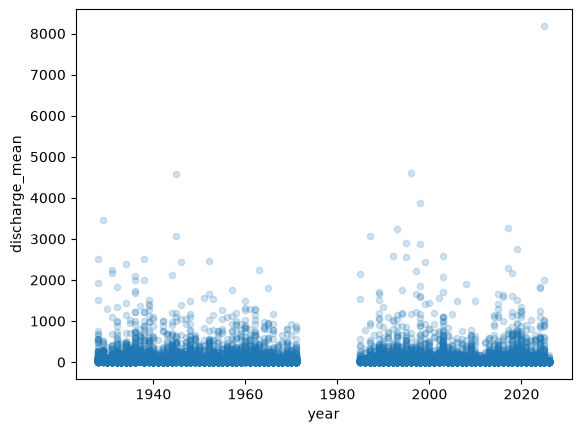

In [110]:
#Plot mean discharge over time
USGS_flow_data.plot(
    kind='scatter',
    y='discharge_mean',
    x='year',
    alpha =0.2
    )

## Closing out
Question: under what circumstances would it be beneficial to use each of these graph types (bar plot, histogram, frequency polygon, box-and whisker, violin, scatterplot)?

> Answer: 

## Ending discussion
What did you learn about the USGS discharge dataset today? What separate insights did the different graph types offer?
> Answer: 


How can multiple options for data exploration inform our understanding of our data?

> Answer: 


Do you see any patterns in the USGS data for the Eno River? What might be responsible for those patterns and/or relationships?

> Answer: 


